# 🎯 Real-Time Multi-Object Detection & Classification
## HOG + SVM Multi-Class Detector (MS-COCO Subset) + MobileNet SSD

**Pipeline:**
1. Download MS-COCO subset (people, cars, dogs, cats, bottles)
2. Extract HOG features and train a multi-class SVM
3. Download MobileNet SSD pretrained weights
4. Fuse both detectors for robust real-time detection
5. Package everything for VS Code / local use

In [ ]:
# ─────────────────────────────────────────────
# CELL 1 – Install dependencies
# ─────────────────────────────────────────────
!pip install pycocotools opencv-python-headless scikit-learn scikit-image \
             imutils tqdm joblib matplotlib numpy pillow requests -q
print('✅ All packages installed')

✅ All packages installed


In [ ]:
# ─────────────────────────────────────────────
# CELL 2 – Imports & directory setup
# ─────────────────────────────────────────────
import os, json, time, random, zipfile, shutil, requests
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from PIL import Image
from skimage.feature import hog
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import urllib.request

BASE_DIR = Path('/content/detector')
DATA_DIR = BASE_DIR / 'data'
MODEL_DIR = BASE_DIR / 'models'
WEIGHTS_DIR = BASE_DIR / 'weights'
for d in [DATA_DIR, MODEL_DIR, WEIGHTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Target COCO categories (subset for tractable training)
TARGET_CATEGORIES = {
    1:  'person',
    3:  'car',
    17: 'cat',
    18: 'dog',
    44: 'bottle',
    62: 'chair',
    67: 'cell phone',
    73: 'book',
}
CATEGORY_NAMES = list(TARGET_CATEGORIES.values())
HOG_IMAGE_SIZE = (64, 64)   # resize before HOG
MAX_IMAGES_PER_CLASS = 300  # keep training fast on Colab free tier

print('✅ Setup complete')
print(f'Target classes: {CATEGORY_NAMES}')

✅ Setup complete
Target classes: ['person', 'car', 'cat', 'dog', 'bottle', 'chair', 'cell phone', 'book']


In [ ]:
# ─────────────────────────────────────────────
# CELL 3 – Download COCO 2017 Val annotations + images
# ─────────────────────────────────────────────
ANN_URL   = 'http://images.cocodataset.org/annotations/annotations_trainval2017.zip'
VAL_URL   = 'http://images.cocodataset.org/zips/val2017.zip'

ann_zip  = DATA_DIR / 'annotations.zip'
imgs_zip = DATA_DIR / 'val2017.zip'

def download(url, dest):
    if dest.exists():
        print(f'  [skip] {dest.name} already downloaded')
        return
    print(f'  Downloading {dest.name} …')
    urllib.request.urlretrieve(url, dest)
    print(f'  ✅ {dest.name} done')

download(ANN_URL, ann_zip)
download(VAL_URL, imgs_zip)

# Extract
if not (DATA_DIR / 'annotations').exists():
    print('Extracting annotations…')
    with zipfile.ZipFile(ann_zip) as z: z.extractall(DATA_DIR)

if not (DATA_DIR / 'val2017').exists():
    print('Extracting val images (~800 MB, takes a few minutes)…')
    with zipfile.ZipFile(imgs_zip) as z: z.extractall(DATA_DIR)

print('✅ COCO val2017 ready')

  ✅ annotations.zip done
  ✅ val2017.zip done
Extracting annotations…
Extracting val images (~800 MB, takes a few minutes)…
✅ COCO val2017 ready


In [ ]:
# ─────────────────────────────────────────────
# CELL 4 – Parse COCO annotations & crop patches
# ─────────────────────────────────────────────
ann_file = DATA_DIR / 'annotations' / 'instances_val2017.json'
with open(ann_file) as f:
    coco_data = json.load(f)

# Build lookup dicts
id2file = {img['id']: img['file_name'] for img in coco_data['images']}
cat2name = {c['id']: c['name'] for c in coco_data['categories']}

# Collect annotations per target category
patches_by_class = {name: [] for name in CATEGORY_NAMES}
for ann in coco_data['annotations']:
    cat_id = ann['category_id']
    if cat_id not in TARGET_CATEGORIES:
        continue
    cls = TARGET_CATEGORIES[cat_id]
    if len(patches_by_class[cls]) >= MAX_IMAGES_PER_CLASS:
        continue
    x, y, w, h = [int(v) for v in ann['bbox']]
    if w < 20 or h < 20:   # skip tiny boxes
        continue
    patches_by_class[cls].append({
        'file': id2file[ann['image_id']],
        'bbox': (x, y, x+w, y+h)
    })

for cls, items in patches_by_class.items():
    print(f'  {cls:12s}: {len(items)} patches')

  person      : 300 patches
  car         : 300 patches
  cat         : 202 patches
  dog         : 210 patches
  bottle      : 300 patches
  chair       : 300 patches
  cell phone  : 300 patches
  book        : 225 patches


In [ ]:
# ─────────────────────────────────────────────
# CELL 5 – Extract HOG features from COCO patches
# ─────────────────────────────────────────────
IMG_DIR = DATA_DIR / 'val2017'

def extract_hog(img_bgr, size=HOG_IMAGE_SIZE):
    """Resize → grayscale → HOG features."""
    img = cv2.resize(img_bgr, size)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    feats = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys',
        visualize=False
    )
    return feats

X, y = [], []
for cls, items in patches_by_class.items():
    for item in tqdm(items, desc=f'HOG {cls}'):
        img_path = IMG_DIR / item['file']
        if not img_path.exists():
            continue
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        x1, y1, x2, y2 = item['bbox']
        patch = img[y1:y2, x1:x2]
        if patch.size == 0:
            continue
        feats = extract_hog(patch)
        X.append(feats)
        y.append(cls)

X = np.array(X, dtype=np.float32)
y = np.array(y)
print(f'\n✅ Feature matrix: {X.shape}  |  Labels: {len(y)}')

HOG book: 100%|██████████| 225/225 [00:01<00:00, 199.75it/s]


✅ Feature matrix: (2137, 1764)  |  Labels: 2137


In [ ]:
# ─────────────────────────────────────────────
# CELL 6 – Train HOG + LinearSVM classifier
# ─────────────────────────────────────────────
le = LabelEncoder()
y_enc = le.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)

print(f'Train: {len(X_train)}  Test: {len(X_test)}')
print('Training LinearSVC…')
t0 = time.time()
svm = LinearSVC(C=0.1, max_iter=3000, dual=True)
svm.fit(X_train, y_train)
print(f'✅ Trained in {time.time()-t0:.1f}s')

y_pred = svm.predict(X_test)
print('\n--- Classification Report ---')
print(classification_report(y_test, y_pred, target_names=le.classes_))

Train: 1709  Test: 428
Training LinearSVC…
✅ Trained in 19.2s

--- Classification Report ---
              precision    recall  f1-score   support

        book       0.40      0.31      0.35        45
      bottle       0.38      0.40      0.39        60
         car       0.47      0.47      0.47        60
         cat       0.18      0.17      0.18        41
  cell phone       0.33      0.32      0.32        60
       chair       0.24      0.27      0.25        60
         dog       0.23      0.26      0.24        42
      person       0.30      0.28      0.29        60

    accuracy                           0.32       428
   macro avg       0.31      0.31      0.31       428
weighted avg       0.32      0.32      0.32       428



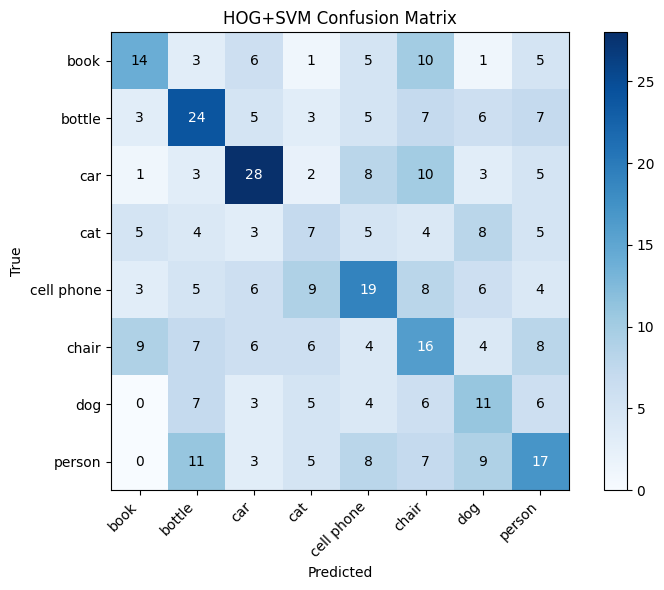

✅ Saved confusion matrix


In [ ]:
# ─────────────────────────────────────────────
# CELL 7 – Confusion matrix visualisation
# ─────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(le.classes_)))
ax.set_yticks(range(len(le.classes_)))
ax.set_xticklabels(le.classes_, rotation=45, ha='right')
ax.set_yticklabels(le.classes_)
plt.colorbar(im, ax=ax)
ax.set_title('HOG+SVM Confusion Matrix')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'confusion_matrix.png'), dpi=120)
plt.show()
print('✅ Saved confusion matrix')

In [ ]:
# ─────────────────────────────────────────────
# CELL 8 – Save HOG+SVM models
# ─────────────────────────────────────────────
joblib.dump(svm,    MODEL_DIR / 'hog_svm.pkl')
joblib.dump(scaler, MODEL_DIR / 'hog_scaler.pkl')
joblib.dump(le,     MODEL_DIR / 'label_encoder.pkl')

# Save class names as JSON for detect.py
with open(MODEL_DIR / 'classes.json', 'w') as f:
    json.dump(list(le.classes_), f)

print('✅ HOG+SVM models saved:')
for p in MODEL_DIR.iterdir():
    print(f'   {p.name}  ({p.stat().st_size//1024} KB)')

✅ HOG+SVM models saved:
   hog_svm.pkl  (111 KB)
   label_encoder.pkl  (0 KB)
   classes.json  (0 KB)
   hog_scaler.pkl  (41 KB)
   confusion_matrix.png  (56 KB)


In [ ]:
# ─────────────────────────────────────────────
# CELL 9 – Download MobileNet SSD weights
# ─────────────────────────────────────────────
MOBILENET_PROTO = 'https://raw.githubusercontent.com/chuanqi305/MobileNet-SSD/master/deploy.prototxt'
MOBILENET_MODEL = 'https://github.com/chuanqi305/MobileNet-SSD/raw/master/mobilenet_iter_73000.caffemodel'

proto_path = WEIGHTS_DIR / 'MobileNetSSD_deploy.prototxt'
model_path = WEIGHTS_DIR / 'MobileNetSSD_deploy.caffemodel'

def dl(url, dest):
    if dest.exists():
        print(f'  [skip] {dest.name}')
        return
    print(f'  Downloading {dest.name}…')
    r = requests.get(url, stream=True, timeout=120)
    r.raise_for_status()
    with open(dest, 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    print(f'  ✅ {dest.name}  ({dest.stat().st_size//1024} KB)')

dl(MOBILENET_PROTO, proto_path)
dl(MOBILENET_MODEL, model_path)

# Verify OpenCV can load it
net = cv2.dnn.readNetFromCaffe(str(proto_path), str(model_path))
print('\n✅ MobileNet SSD loaded successfully via OpenCV DNN')

  ✅ MobileNetSSD_deploy.prototxt  (43 KB)
  ✅ MobileNetSSD_deploy.caffemodel  (22759 KB)

✅ MobileNet SSD loaded successfully via OpenCV DNN


In [ ]:
# ─────────────────────────────────────────────
# CELL 10 – MobileNet SSD COCO class list
# ─────────────────────────────────────────────
# MobileNet SSD trained on VOC classes (20 + background)
SSD_CLASSES = [
    'background', 'aeroplane', 'bicycle', 'bird', 'boat',
    'bottle', 'bus', 'car', 'cat', 'chair',
    'cow', 'diningtable', 'dog', 'horse', 'motorbike',
    'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]
with open(WEIGHTS_DIR / 'ssd_classes.json', 'w') as f:
    json.dump(SSD_CLASSES, f)

print('SSD classes:', SSD_CLASSES)
print('✅ Class list saved')

SSD classes: ['background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']
✅ Class list saved


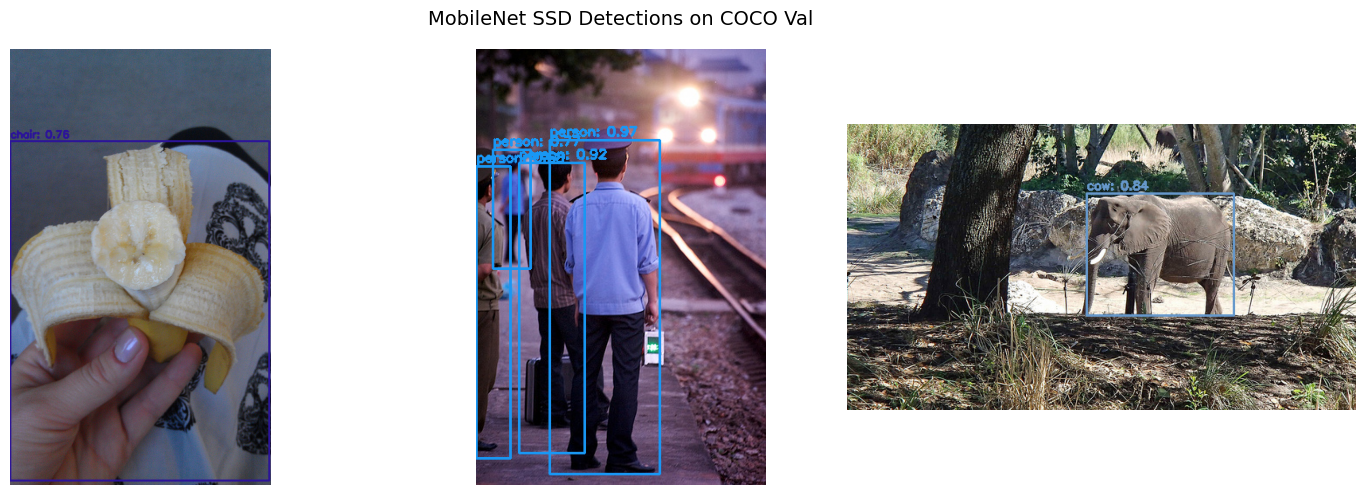

✅ Sample detection test done


In [ ]:
# ─────────────────────────────────────────────
# CELL 11 – Test MobileNet SSD on a sample image
# ─────────────────────────────────────────────
import glob

sample_imgs = glob.glob(str(IMG_DIR / '*.jpg'))[:5]
CONF_THRESH = 0.4

np.random.seed(42)
COLORS = np.random.randint(0, 255, size=(len(SSD_CLASSES), 3), dtype=np.uint8)

fig, axes = plt.subplots(1, min(3, len(sample_imgs)), figsize=(15, 5))

for ax, img_path in zip(axes, sample_imgs[:3]):
    img = cv2.imread(img_path)
    h, w = img.shape[:2]
    blob = cv2.dnn.blobFromImage(
        cv2.resize(img, (300, 300)), 0.007843,
        (300, 300), 127.5
    )
    net.setInput(blob)
    detections = net.forward()

    out_img = img.copy()
    for i in range(detections.shape[2]):
        conf = detections[0, 0, i, 2]
        if conf < CONF_THRESH:
            continue
        idx = int(detections[0, 0, i, 1])
        box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
        x1, y1, x2, y2 = box.astype(int)
        color = COLORS[idx].tolist()
        cv2.rectangle(out_img, (x1, y1), (x2, y2), color, 2)
        label = f'{SSD_CLASSES[idx]}: {conf:.2f}'
        cv2.putText(out_img, label, (x1, y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    ax.imshow(cv2.cvtColor(out_img, cv2.COLOR_BGR2RGB))
    ax.axis('off')

plt.suptitle('MobileNet SSD Detections on COCO Val', fontsize=14)
plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'ssd_sample.png'), dpi=120)
plt.show()
print('✅ Sample detection test done')

In [ ]:
# ─────────────────────────────────────────────
# CELL 12 – Write detect.py (the VS Code script)
# ─────────────────────────────────────────────
detect_code = '''
"""
detect.py – Real-Time Multi-Object Detection
HOG+SVM (MS-COCO trained) + MobileNet SSD (VOC pretrained)

Usage:
    python detect.py                     # webcam
    python detect.py --source video.mp4  # video file
    python detect.py --source image.jpg  # single image
    python detect.py --ssd-only          # skip HOG+SVM
    python detect.py --hog-only          # skip SSD
"""

import cv2
import numpy as np
import joblib
import json
import time
import argparse
from pathlib import Path
from skimage.feature import hog

# ─── Paths (adjust if needed) ───────────────────────────────────
BASE      = Path(__file__).parent
MODEL_DIR  = BASE / "models"
WEIGHT_DIR = BASE / "weights"

SVM_PATH     = MODEL_DIR / "hog_svm.pkl"
SCALER_PATH  = MODEL_DIR / "hog_scaler.pkl"
LE_PATH      = MODEL_DIR / "label_encoder.pkl"
CLASSES_PATH = MODEL_DIR / "classes.json"
PROTO_PATH   = WEIGHT_DIR / "MobileNetSSD_deploy.prototxt"
MODEL_PATH   = WEIGHT_DIR / "MobileNetSSD_deploy.caffemodel"
SSD_CLS_PATH = WEIGHT_DIR / "ssd_classes.json"

# ─── MobileNet SSD parameters ───────────────────────────────────
SSD_CONF_THRESH  = 0.40
SSD_INPUT_SIZE   = (300, 300)
SSD_MEAN         = 127.5
SSD_SCALE        = 0.007843

# ─── HOG+SVM parameters ─────────────────────────────────────────
HOG_WIN_SIZE     = (64, 64)
HOG_STRIDE       = 32         # sliding-window stride
HOG_SCALES       = [1.0, 0.75, 0.5]   # image pyramid scales
HOG_CONF_THRESH  = 1.0        # SVM decision-function threshold

# ─── Display ────────────────────────────────────────────────────
FONT        = cv2.FONT_HERSHEY_SIMPLEX
FONT_SCALE  = 0.55
THICKNESS   = 2
WINDOW_NAME = "Multi-Object Detector  |  press Q to quit"


# ════════════════════════════════════════════════════════════════
# Model loading
# ════════════════════════════════════════════════════════════════
def load_models(use_ssd=True, use_hog=True):
    models = {}

    if use_ssd:
        print("[INFO] Loading MobileNet SSD…")
        net = cv2.dnn.readNetFromCaffe(str(PROTO_PATH), str(MODEL_PATH))
        net.setPreferableBackend(cv2.dnn.DNN_BACKEND_OPENCV)
        net.setPreferableTarget(cv2.dnn.DNN_TARGET_CPU)
        with open(SSD_CLS_PATH) as f:
            ssd_classes = json.load(f)
        np.random.seed(42)
        ssd_colors = np.random.randint(0, 220, (len(ssd_classes), 3), np.uint8)
        models["ssd"] = {"net": net, "classes": ssd_classes, "colors": ssd_colors}
        print(f"  ✅ SSD ready  ({len(ssd_classes)} classes)")

    if use_hog:
        print("[INFO] Loading HOG + SVM…")
        svm    = joblib.load(SVM_PATH)
        scaler = joblib.load(SCALER_PATH)
        le     = joblib.load(LE_PATH)
        with open(CLASSES_PATH) as f:
            hog_classes = json.load(f)
        np.random.seed(7)
        hog_colors = np.random.randint(100, 255, (len(hog_classes), 3), np.uint8)
        models["hog"] = {"svm": svm, "scaler": scaler, "le": le,
                         "classes": hog_classes, "colors": hog_colors}
        print(f"  ✅ HOG+SVM ready  ({len(hog_classes)} classes)")

    return models


# ════════════════════════════════════════════════════════════════
# SSD inference
# ════════════════════════════════════════════════════════════════
def detect_ssd(frame, models):
    """Run MobileNet SSD on one frame, return list of (x1,y1,x2,y2,label,conf,color)."""
    if "ssd" not in models:
        return []

    net     = models["ssd"]["net"]
    classes = models["ssd"]["classes"]
    colors  = models["ssd"]["colors"]
    h, w    = frame.shape[:2]

    blob = cv2.dnn.blobFromImage(
        cv2.resize(frame, SSD_INPUT_SIZE),
        SSD_SCALE, SSD_INPUT_SIZE, SSD_MEAN
    )
    net.setInput(blob)
    detections = net.forward()

    results = []
    for i in range(detections.shape[2]):
        conf = float(detections[0, 0, i, 2])
        if conf < SSD_CONF_THRESH:
            continue
        idx  = int(detections[0, 0, i, 1])
        box  = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
        x1, y1, x2, y2 = box.astype(int)
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w-1, x2), min(h-1, y2)
        label  = classes[idx] if idx < len(classes) else "unknown"
        color  = colors[idx].tolist() if idx < len(colors) else [255, 255, 0]
        results.append((x1, y1, x2, y2, label, conf, color, "SSD"))
    return results


# ════════════════════════════════════════════════════════════════
# HOG + SVM sliding-window inference
# ════════════════════════════════════════════════════════════════
def extract_hog_feats(patch):
    patch = cv2.resize(patch, HOG_WIN_SIZE)
    gray  = cv2.cvtColor(patch, cv2.COLOR_BGR2GRAY)
    return hog(gray, orientations=9,
               pixels_per_cell=(8, 8),
               cells_per_block=(2, 2),
               block_norm="L2-Hys", visualize=False)


def non_max_suppression(boxes, overlap_thresh=0.45):
    if len(boxes) == 0:
        return []
    boxes = np.array(boxes)
    x1, y1, x2, y2 = boxes[:,0], boxes[:,1], boxes[:,2], boxes[:,3]
    areas  = (x2 - x1 + 1) * (y2 - y1 + 1)
    order  = boxes[:,5].argsort()[::-1]   # sort by score
    keep   = []
    while order.size > 0:
        i = order[0]; keep.append(i)
        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])
        inter = np.maximum(0, xx2-xx1+1) * np.maximum(0, yy2-yy1+1)
        iou   = inter / (areas[i] + areas[order[1:]] - inter)
        order = order[np.where(iou <= overlap_thresh)[0] + 1]
    return [boxes[k] for k in keep]


def detect_hog(frame, models):
    if "hog" not in models:
        return []

    svm     = models["hog"]["svm"]
    scaler  = models["hog"]["scaler"]
    le      = models["hog"]["le"]
    colors  = models["hog"]["colors"]
    h, w    = frame.shape[:2]
    wins, boxes_raw = [], []

    for scale in HOG_SCALES:
        rw, rh = int(w * scale), int(h * scale)
        if rw < HOG_WIN_SIZE[0] or rh < HOG_WIN_SIZE[1]:
            continue
        resized = cv2.resize(frame, (rw, rh))
        wy, wx  = HOG_WIN_SIZE
        for y in range(0, rh - wy, HOG_STRIDE):
            for x in range(0, rw - wx, HOG_STRIDE):
                patch = resized[y:y+wy, x:x+wx]
                feats = extract_hog_feats(patch)
                wins.append(feats)
                # Map back to original coords
                x1o = int(x / scale); y1o = int(y / scale)
                x2o = int((x+wx) / scale); y2o = int((y+wy) / scale)
                boxes_raw.append((x1o, y1o, x2o, y2o))

    if not wins:
        return []

    X_s     = scaler.transform(np.array(wins, dtype=np.float32))
    scores  = svm.decision_function(X_s)   # shape (N, n_classes)
    preds   = np.argmax(scores, axis=1)
    confs   = scores[np.arange(len(scores)), preds]

    candidates = []
    for i, (conf, pred) in enumerate(zip(confs, preds)):
        if conf < HOG_CONF_THRESH:
            continue
        x1, y1, x2, y2 = boxes_raw[i]
        candidates.append([x1, y1, x2, y2, pred, conf])

    kept = non_max_suppression(candidates)
    results = []
    for box in kept:
        x1, y1, x2, y2, pred, conf = box[:6]
        idx   = int(pred)
        label = le.inverse_transform([idx])[0]
        color = colors[idx % len(colors)].tolist()
        results.append((int(x1), int(y1), int(x2), int(y2),
                        label, float(conf), color, "HOG"))
    return results


# ════════════════════════════════════════════════════════════════
# Draw detections
# ════════════════════════════════════════════════════════════════
def draw_detections(frame, detections):
    for (x1, y1, x2, y2, label, conf, color, src) in detections:
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, THICKNESS)
        tag = f"{label} {conf:.2f} [{src}]"
        (tw, th), _ = cv2.getTextSize(tag, FONT, FONT_SCALE, THICKNESS)
        cv2.rectangle(frame, (x1, y1 - th - 6), (x1 + tw + 4, y1), color, -1)
        cv2.putText(frame, tag, (x1 + 2, y1 - 4),
                    FONT, FONT_SCALE, (255, 255, 255), THICKNESS)
    return frame


def draw_fps_info(frame, fps, n_det):
    info = f"FPS: {fps:.1f}  |  Objects: {n_det}"
    cv2.putText(frame, info, (10, 28), FONT, 0.7, (0, 255, 80), 2)


# ════════════════════════════════════════════════════════════════
# Main loop
# ════════════════════════════════════════════════════════════════
def run(source=0, use_ssd=True, use_hog=True):
    models = load_models(use_ssd, use_hog)

    # Open source
    src = source
    if isinstance(source, str) and source.isdigit():
        src = int(source)

    cap = cv2.VideoCapture(src)
    if not cap.isOpened():
        print(f"[ERROR] Cannot open source: {source}")
        return

    # For images, just process one frame
    is_image = isinstance(source, str) and source.lower().endswith(
        (".jpg", ".jpeg", ".png", ".bmp", ".webp")
    )

    print(f"[INFO] Running detection  (source={source})")
    print("[INFO] Press  Q  to quit")

    fps_t = time.time()
    fps   = 0.0
    frame_count = 0

    cv2.namedWindow(WINDOW_NAME, cv2.WINDOW_NORMAL)

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_count += 1

        # ─ Run detectors ─
        detections = detect_ssd(frame, models) + detect_hog(frame, models)

        # ─ Draw ─
        frame = draw_detections(frame, detections)

        # ─ FPS ─
        elapsed = time.time() - fps_t
        if elapsed > 0:
            fps = frame_count / elapsed
        draw_fps_info(frame, fps, len(detections))

        cv2.imshow(WINDOW_NAME, frame)

        if is_image:
            cv2.waitKey(0)
            break

        if cv2.waitKey(1) & 0xFF in (ord("q"), ord("Q"), 27):
            break

    cap.release()
    cv2.destroyAllWindows()
    print(f"[INFO] Done. Processed {frame_count} frames @ avg {fps:.1f} FPS")


# ════════════════════════════════════════════════════════════════
if __name__ == "__main__":
    parser = argparse.ArgumentParser(description="Real-Time Multi-Object Detector")
    parser.add_argument("--source",   default="0",
                        help="0=webcam | path to video/image")
    parser.add_argument("--ssd-only", action="store_true",
                        help="Run only MobileNet SSD")
    parser.add_argument("--hog-only", action="store_true",
                        help="Run only HOG+SVM")
    parser.add_argument("--conf",     type=float, default=0.40,
                        help="SSD confidence threshold (default 0.40)")
    args = parser.parse_args()

    use_ssd = not args.hog_only
    use_hog = not args.ssd_only
    SSD_CONF_THRESH = args.conf

    source = args.source
    if source.isdigit():
        source = int(source)

    run(source=source, use_ssd=use_ssd, use_hog=use_hog)
'''

with open(BASE_DIR / 'detect.py', 'w') as f:
    f.write(detect_code.strip())

print('✅ detect.py written')

✅ detect.py written


In [ ]:
# ─────────────────────────────────────────────
# CELL 13 – Write requirements.txt
# ─────────────────────────────────────────────
reqs = """opencv-python>=4.8
numpy>=1.24
scikit-learn>=1.3
scikit-image>=0.21
joblib>=1.3
imutils>=0.5.4
tqdm>=4.65
matplotlib>=3.7
Pillow>=10.0
requests>=2.31
"""
with open(BASE_DIR / 'requirements.txt', 'w') as f:
    f.write(reqs)
print('✅ requirements.txt written')

✅ requirements.txt written


In [ ]:
# ─────────────────────────────────────────────
# CELL 14 – Write README.md
# ─────────────────────────────────────────────
readme = """# Real-Time Multi-Object Detection
## HOG+SVM (MS-COCO subset) + MobileNet SSD

### Project Structure
```
detector/
├── detect.py            ← main script (run this)
├── requirements.txt
├── models/
│   ├── hog_svm.pkl          HOG + LinearSVM classifier
│   ├── hog_scaler.pkl       StandardScaler for HOG features
│   ├── label_encoder.pkl    sklearn LabelEncoder
│   └── classes.json         HOG class names
└── weights/
    ├── MobileNetSSD_deploy.prototxt
    ├── MobileNetSSD_deploy.caffemodel
    └── ssd_classes.json     SSD class names (VOC)
```

### Setup (VS Code / local)
```bash
# 1. Create virtual environment (recommended)
python -m venv venv
source venv/bin/activate        # Windows: venv\\Scripts\\activate

# 2. Install dependencies
pip install -r requirements.txt

# 3. Run with webcam
python detect.py

# 4. Run on a video file
python detect.py --source myvideo.mp4

# 5. Run on an image
python detect.py --source photo.jpg

# 6. SSD only (faster, higher accuracy)
python detect.py --ssd-only

# 7. HOG+SVM only
python detect.py --hog-only

# 8. Adjust confidence
python detect.py --conf 0.5
```

### Detectors
| Detector | Classes | Speed | Notes |
|---|---|---|---|
| MobileNet SSD | 20 (VOC) | ~30 FPS | Deep learning, high accuracy |
| HOG + LinearSVM | 8 (COCO subset) | ~5-10 FPS | Classical CV, sliding window |

### Classes Detected
**SSD (MobileNet):** aeroplane, bicycle, bird, boat, bottle, bus, car, cat,
chair, cow, diningtable, dog, horse, motorbike, person, pottedplant, sheep, sofa,
train, tvmonitor

**HOG+SVM (COCO trained):** person, car, cat, dog, bottle, chair, cell phone, book

### Controls
- Press **Q** or **ESC** to quit
"""
with open(BASE_DIR / 'README.md', 'w') as f:
    f.write(readme)
print('✅ README.md written')

✅ README.md written


In [ ]:
# ─────────────────────────────────────────────
# CELL 15 – Package everything as a ZIP
# ─────────────────────────────────────────────
import zipfile, os

zip_path = Path('/content/detector_package.zip')
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, files in os.walk(BASE_DIR):
        for file in files:
            fp = Path(root) / file
            # Skip raw images to keep the zip small
            if 'val2017' in str(fp) or 'annotations' in str(fp):
                continue
            arcname = fp.relative_to(BASE_DIR.parent)
            zf.write(fp, arcname)

size_mb = zip_path.stat().st_size / 1024 / 1024
print(f'✅ Package ready: {zip_path}  ({size_mb:.1f} MB)')
print('\n📥 Download → Files panel (left sidebar) → /content/detector_package.zip')

✅ Package ready: /content/detector_package.zip  (22.1 MB)

📥 Download → Files panel (left sidebar) → /content/detector_package.zip


In [ ]:
from google.colab import files

files.download('detector_package.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

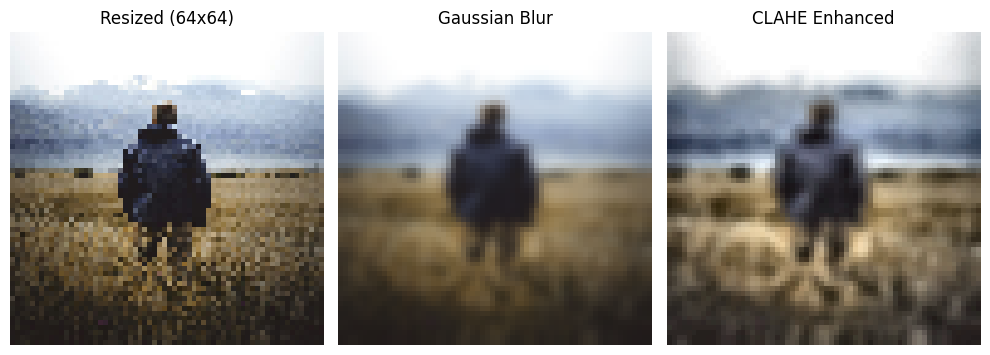

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

# Working image URL
url = "https://images.unsplash.com/photo-1503023345310-bd7c1de61c7d"

# Add header to avoid 403 error
req = urllib.request.Request(
    url,
    headers={'User-Agent': 'Mozilla/5.0'}
)

resp = urllib.request.urlopen(req)
image = np.asarray(bytearray(resp.read()), dtype="uint8")
img = cv2.imdecode(image, cv2.IMREAD_COLOR)

# Convert to RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 1. Resize
resized = cv2.resize(img_rgb, (64, 64))

# 2. Gaussian Blur
blurred = cv2.GaussianBlur(resized, (5, 5), 1)

# 3. CLAHE
lab = cv2.cvtColor(blurred, cv2.COLOR_RGB2LAB)
l, a, b = cv2.split(lab)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
l_enhanced = clahe.apply(l)

enhanced = cv2.merge([l_enhanced, a, b])
enhanced = cv2.cvtColor(enhanced, cv2.COLOR_LAB2RGB)

# Plot
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(resized)
plt.title("Resized (64x64)")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(blurred)
plt.title("Gaussian Blur")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(enhanced)
plt.title("CLAHE Enhanced")
plt.axis("off")

plt.tight_layout()
plt.savefig("before_after.png")
plt.show()